# 조합B + Daily_Return 모델 4종 비교

기존 조합 B에 `daily_return`을 추가한 뒤 같은 12폴드 워크포워드에서
모델 네 종을 비교한다. 아래 코드는 이 폴더의 01~04 원본 노트북을 다시 실행해
결과 변수를 직접 가져오므로 비교 숫자를 손으로 옮겨 적지 않는다.

## 공통 실험 조건

| 항목 | 값 |
|---|---|
| 추가 피처 | `daily_return` |
| 정답 | 미래 5거래일 방향: 하락 `-1`, 중립 `0`, 상승 `1` |
| 검증 | 시간순 확장형 워크포워드 12폴드 |
| 최초 학습 | 750개 |
| 폴드별 검증 | 60개 |
| 학습·검증 사이 gap | 5개 |
| 전체 OOS | 720개: 하락 204, 중립 306, 상승 210 |
| 클래스 가중치 | 네 모델 모두 `balanced` |

기존 조합에서 선택한 모델별 클래스 가중치를 그대로 유지한다. 네 모델의 검증 행과
실제 정답은 완전히 같다.


Logistic (balanced): 원본 노트북 변수 수집 완료


RandomForest (balanced): 원본 노트북 변수 수집 완료


XGBoost (balanced): 원본 노트북 변수 수집 완료


LightGBM (balanced): 원본 노트북 변수 수집 완료


지표,Accuracy,Balanced Accuracy,Macro F1
모델,,,
LightGBM (balanced),0.3528,0.3394,0.3389
Logistic (balanced),0.3736,0.3445,0.3184
RandomForest (balanced),0.3389,0.3253,0.3243
XGBoost (balanced),0.3792,0.3625,0.3640


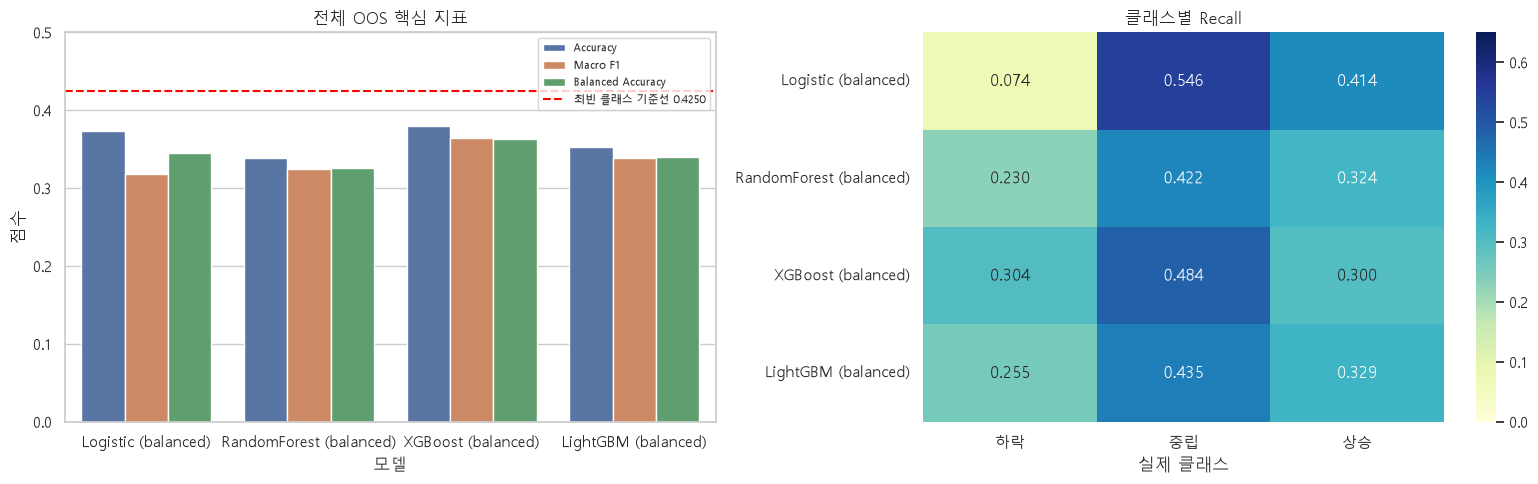


## 자동 비교 해석

- **Accuracy 1위:** `XGBoost (balanced)` `0.3792`
- **Macro F1 1위:** `XGBoost (balanced)` `0.3640`
- **하락 Recall 1위:** `XGBoost (balanced)` `0.3039`
- Accuracy 1위도 최빈 클래스 기준선 `0.4250` 대비
  `-0.0458`이다.

네 모델 모두 기본 가중치와 balanced를 비교한 후, Macro F1과 balanced accuracy가
높은 balanced를 최종 설정으로 적용한 결과다. 따라서 Accuracy 우선과
클래스 균형·하락 탐지 우선의 선택이 다르다.
다만 최고 Accuracy도 최빈 클래스 기준선을 넘지 못하면 최종 매매 신호로 채택할
근거가 없다. 이 값은 같은 개발 OOS 구간에서 여러 모델을 비교한 결과이므로 별도
홀드아웃을 열기 전까지 개발구간 결과로만 취급한다.


In [1]:
# 네 원본 노트북을 실행하고 그 안에서 계산된 변수를 직접 가져옵니다.
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython import get_ipython
from IPython.display import Markdown, display
from IPython.utils.capture import capture_output

# Windows에서 한글과 음수 기호가 깨지지 않도록 글꼴을 지정합니다.
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 현재 위치가 저장소 루트와 노트북 폴더 중 어디든 실행되도록 실험 폴더를 찾습니다.
current_path = Path.cwd().resolve()
experiment_name = "조합B + Daily_Return"
if current_path.name == experiment_name:
    experiment_dir = current_path
else:
    experiment_dir = (
        current_path
        / "notebooks"
        / "04-모델"
        / "실험"
        / experiment_name
    )
if not experiment_dir.is_dir():
    raise RuntimeError(f"조합B + Daily_Return 실험 폴더를 찾지 못했습니다: {experiment_dir}")

model_notebooks = {
    "Logistic (balanced)": "01.LogisticRegression.ipynb",
    "RandomForest (balanced)": "02.RandomForest.ipynb",
    "XGBoost (balanced)": "03.XGBoost.ipynb",
    "LightGBM (balanced)": "04.LightGBM.ipynb",
}

ipython = get_ipython()
if ipython is None:
    raise RuntimeError("이 비교 코드는 Jupyter/IPython 커널에서 실행해야 합니다.")

results = {}
for model_name, filename in model_notebooks.items():
    source_notebook = (experiment_dir / filename).resolve()
    if not source_notebook.is_file():
        raise FileNotFoundError(source_notebook)

    # 원본 노트북의 긴 중간 출력은 숨기되 계산 자체는 그대로 실행합니다.
    with capture_output():
        ipython.run_line_magic("run", f'"{source_notebook}"')

    # %run은 원본 노트북 변수를 현재 커널에 남기므로 복사본을 즉시 보관합니다.
    summary_result = ipython.user_ns.get("summary")
    matrix_result = ipython.user_ns.get("confusion_matrix_df")
    if summary_result is None or matrix_result is None:
        raise RuntimeError(f"{model_name} 실행 결과 변수를 찾지 못했습니다.")

    results[model_name] = {
        "scores": [
            float(summary_result["전체 OOS accuracy"]),
            float(summary_result["전체 OOS macro F1"]),
            float(summary_result["전체 OOS balanced accuracy"]),
        ],
        "matrix": matrix_result.to_numpy(dtype=int).copy(),
    }
    print(f"{model_name}: 원본 노트북 변수 수집 완료")

# 원본 변수를 사람이 비교하기 쉬운 표로 변환합니다.
score_names = ["Accuracy", "Macro F1", "Balanced Accuracy"]
score_rows = [
    {"모델": model, "지표": score_name, "값": value}
    for model, result in results.items()
    for score_name, value in zip(score_names, result["scores"], strict=True)
]
score_df = pd.DataFrame(score_rows)
display(score_df.pivot(index="모델", columns="지표", values="값").round(4))

figure, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=score_df, x="모델", y="값", hue="지표", ax=axes[0])
axes[0].axhline(
    0.4250,
    color="red",
    linestyle="--",
    label="최빈 클래스 기준선 0.4250",
)
axes[0].set_ylim(0, 0.5)
axes[0].set_title("전체 OOS 핵심 지표")
axes[0].set_ylabel("점수")
axes[0].legend(fontsize=8)

# 각 혼동행렬의 대각선을 실제 클래스 표본 수로 나눠 Recall을 계산합니다.
recall_rows = {}
for model, result in results.items():
    matrix = result["matrix"]
    recall_rows[model] = [
        matrix[index, index] / matrix[index].sum()
        for index in range(3)
    ]
recall_df = pd.DataFrame(recall_rows, index=["하락", "중립", "상승"]).T
sns.heatmap(
    recall_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0,
    vmax=0.65,
    ax=axes[1],
)
axes[1].set_title("클래스별 Recall")
axes[1].set_xlabel("실제 클래스")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


# 수집한 변수에서 우수 모델과 기준선 차이를 계산해 해석도 자동으로 만듭니다.
score_pivot_df = score_df.pivot(index="모델", columns="지표", values="값")
best_accuracy_model = score_pivot_df["Accuracy"].idxmax()
best_macro_f1_model = score_pivot_df["Macro F1"].idxmax()
best_down_recall_model = recall_df["하락"].idxmax()
best_accuracy = float(score_pivot_df.loc[best_accuracy_model, "Accuracy"])
best_macro_f1 = float(score_pivot_df.loc[best_macro_f1_model, "Macro F1"])
best_down_recall = float(recall_df.loc[best_down_recall_model, "하락"])
majority_baseline = 0.4250

display(
    Markdown(
        f"""
## 자동 비교 해석

- **Accuracy 1위:** `{best_accuracy_model}` `{best_accuracy:.4f}`
- **Macro F1 1위:** `{best_macro_f1_model}` `{best_macro_f1:.4f}`
- **하락 Recall 1위:** `{best_down_recall_model}` `{best_down_recall:.4f}`
- Accuracy 1위도 최빈 클래스 기준선 `{majority_baseline:.4f}` 대비
  `{best_accuracy - majority_baseline:+.4f}`이다.

네 모델 모두 기본 가중치와 balanced를 비교한 후, Macro F1과 balanced accuracy가
높은 balanced를 최종 설정으로 적용한 결과다. 따라서 Accuracy 우선과
클래스 균형·하락 탐지 우선의 선택이 다르다.
다만 최고 Accuracy도 최빈 클래스 기준선을 넘지 못하면 최종 매매 신호로 채택할
근거가 없다. 이 값은 같은 개발 OOS 구간에서 여러 모델을 비교한 결과이므로 별도
홀드아웃을 열기 전까지 개발구간 결과로만 취급한다.
"""
    )
)


## 조합B + Daily_Return 개별 실험

- [Logistic Regression](01.LogisticRegression.ipynb)
- [RandomForest](02.RandomForest.ipynb)
- [XGBoost](03.XGBoost.ipynb)
- [LightGBM](04.LightGBM.ipynb)
